Import delle librerie

In [1]:
import pandas as pd
import os
import numpy as np
import torch
import time
import json
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.utils import resample

/Users/rubengigante/Angel/ProgettoData_Web/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Configurazione del Device

Separare il controllo del hardware permette di verificare subito se la GPU è rilevata correttamente.


In [2]:
# Controllo del device: MPS per Mac M1/M2/M3, CUDA per GPU Nvidia, altrimenti CPU
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Device rilevato: MPS (Mac GPU)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Device rilevato: CUDA (Nvidia GPU)")
else:
    device = torch.device("cpu")
    print("Device rilevato: CPU")

Device rilevato: MPS (Mac GPU)


Caricamento dati
Carichiamo i dataset e definiamo i nomi delle colonne.

In [ ]:
train_df = pd.read_csv('../data/train_set.csv')
test_df = pd.read_csv('../data/test_set.csv')

# Visualizzazione rapida per sicurezza
print(f"Train set: {train_df.shape}")
print(f"Test set: {test_df.shape}")

text_column = 'text' 
label_column = 'label'

Train set: (32650, 2)
Test set: (13994, 2)


Inizializzazione del Modello LLM (DistilBERT)

Scarichiamo il modello e il tokenizer.

In [4]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)

# Mettiamo il modello in modalità valutazione (disabilita dropout, ecc.)
model.eval()

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 5971.56it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

Definizione della funzione di estrazione

Definiamo la logica di estrazione senza eseguirla.

In [5]:
def extract_embeddings(text_list, batch_size=32, max_length=128):
    all_embeddings = []
    
    # Processiamo a blocchi (batch) per non esaurire la memoria
    for i in tqdm(range(0, len(text_list), batch_size), desc="Estrazione in corso"):
        batch_text = text_list[i : i + batch_size].tolist()
        
        # Tokenizzazione del batch
        inputs = tokenizer(batch_text, 
                           padding=True, 
                           truncation=True, 
                           max_length=max_length, 
                           return_tensors="pt").to(device)
        
        with torch.no_grad(): # Importante: non calcolare i gradienti!
            outputs = model(**inputs)
            # Prendiamo lo stato nascosto dell'ultimo livello relativo al primo token [CLS]
            # Dimensione: (batch_size, 768)
            cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            all_embeddings.append(cls_embeddings)
            
    return np.vstack(all_embeddings)

Esecuzione Estrazione Embedding

Questa è la cella più onerosa computazionalmente. 

In [7]:
print("Estrazione embedding per il Train Set...")
X_train_llm = extract_embeddings(train_df[text_column])

print("\nEstrazione embedding per il Test Set...")
X_test_llm = extract_embeddings(test_df[text_column])

y_train = train_df[label_column].values
y_test = test_df[label_column].values

print(f"\nMatrice finale Train: {X_train_llm.shape}")

Estrazione embedding per il Train Set...


Estrazione in corso: 100%|██████████| 1021/1021 [04:24<00:00,  3.86it/s]



Estrazione embedding per il Test Set...


Estrazione in corso: 100%|██████████| 438/438 [02:06<00:00,  3.47it/s]


Matrice finale Train: (32650, 768)


Salvataggio su disco (Checkpoint)

In [8]:
# Salvataggio degli embedding nella cartella data posizionata al livello superiore
if not os.path.exists('../data/'):
    os.makedirs('../data/')

np.save('../data/X_train_distilbert.npy', X_train_llm)
np.save('../data/X_test_distilbert.npy', X_test_llm)

print("Embedding salvati correttamente in ../data/")

Embedding salvati correttamente in ../data/


Configurazione Esperimento e Helper Metrics

Prepariamo le strutture dati e la funzione per raccogliere i risultati.

In [9]:
# 1. Configurazione Esperimento
exp_name = "DistilBERT_Embeddings"
final_results = {exp_name: {}}

# Helper function per le metriche
def get_metrics_dict(y_true, y_pred, grid_obj):
    return {
        "best_params": grid_obj.best_params_,
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, average='macro')),
        "recall": float(recall_score(y_true, y_pred, average='macro')),
        "f1_score": float(f1_score(y_true, y_pred, average='macro')),
        "confusion_matrix": confusion_matrix(y_true, y_pred).tolist()
    }

# Helper function per stampare le metriche a video
def print_metrics(model_name, metrics):
    print(f"\n--- RISULTATI {model_name.upper()} ---")
    print(f"Migliori Parametri: {metrics['best_params']}")
    print(f"Accuracy:  {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall:    {metrics['recall']:.4f}")
    print(f"F1-Score:  {metrics['f1_score']:.4f}")
    print("-" * 30)

# 2. Subset per GridSearch
print(f"[{exp_name}] Campionamento subset per GridSearch...")
X_tune, y_tune = resample(X_train_llm, y_train, n_samples=8000, random_state=42, stratify=y_train)

[DistilBERT_Embeddings] Campionamento subset per GridSearch...


Training - Logistic Regression

In [10]:
print(f"[{exp_name}] Tuning & Training Logistic Regression...")
lr = LogisticRegression(max_iter=500, class_weight='balanced', random_state=42)
grid_lr = GridSearchCV(lr, {'C': [0.1, 1, 10]}, cv=3, scoring='f1_macro', n_jobs=-1)
grid_lr.fit(X_tune, y_tune)

best_lr = grid_lr.best_estimator_
best_lr.fit(X_train_llm, y_train)
y_pred_lr = best_lr.predict(X_test_llm)

# Salvataggio e Stampa
res_lr = get_metrics_dict(y_test, y_pred_lr, grid_lr)
final_results[exp_name]["logistic_regression"] = res_lr
print_metrics("Logistic Regression", res_lr)

[DistilBERT_Embeddings] Tuning & Training Logistic Regression...

--- RISULTATI LOGISTIC REGRESSION ---
Migliori Parametri: {'C': 1}
Accuracy:  0.8738
Precision: 0.8743
Recall:    0.8738
F1-Score:  0.8738
------------------------------


Training - Decision Tree

In [11]:
print(f"[{exp_name}] Tuning & Training Decision Tree...")
dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)
grid_dt = GridSearchCV(dt, {'max_depth': [5, 10]}, cv=3, scoring='f1_macro', n_jobs=-1)
grid_dt.fit(X_tune, y_tune)

best_dt = grid_dt.best_estimator_
best_dt.fit(X_train_llm, y_train)
y_pred_dt = best_dt.predict(X_test_llm)

# Salvataggio e Stampa
res_dt = get_metrics_dict(y_test, y_pred_dt, grid_dt)
final_results[exp_name]["decision_tree"] = res_dt
print_metrics("Decision Tree", res_dt)

[DistilBERT_Embeddings] Tuning & Training Decision Tree...

--- RISULTATI DECISION TREE ---
Migliori Parametri: {'max_depth': 10}
Accuracy:  0.7577
Precision: 0.7586
Recall:    0.7577
F1-Score:  0.7575
------------------------------


Training - SVM

In [12]:
print(f"[{exp_name}] Tuning & Training SVM (SVC)...")
svm = SVC(class_weight='balanced', random_state=42)
grid_svm = GridSearchCV(svm, {'C': [0.1, 1], 'kernel': ['linear', 'rbf']}, cv=3, scoring='f1_macro', n_jobs=-1)
grid_svm.fit(X_tune, y_tune)

best_svm = grid_svm.best_estimator_
best_svm.fit(X_train_llm, y_train)
y_pred_svm = best_svm.predict(X_test_llm)

# Salvataggio e Stampa
res_svm = get_metrics_dict(y_test, y_pred_svm, grid_svm)
final_results[exp_name]["svm"] = res_svm
print_metrics("SVM", res_svm)

[DistilBERT_Embeddings] Tuning & Training SVM (SVC)...

--- RISULTATI SVM ---
Migliori Parametri: {'C': 1, 'kernel': 'linear'}
Accuracy:  0.8759
Precision: 0.8771
Recall:    0.8759
F1-Score:  0.8758
------------------------------


Esportazione Risultati

In [13]:
if not os.path.exists('../results/'):
    os.makedirs('../results/')

json_path = f"../results/metrics_{exp_name.lower()}.json"
with open(json_path, 'w') as f:
    json.dump(final_results, f, indent=4)
print(f"\nEsperimento completato. Metriche salvate in: {json_path}")


Esperimento completato. Metriche salvate in: ../results/metrics_distilbert_embeddings.json


Visualizzazione Matrici di confusione

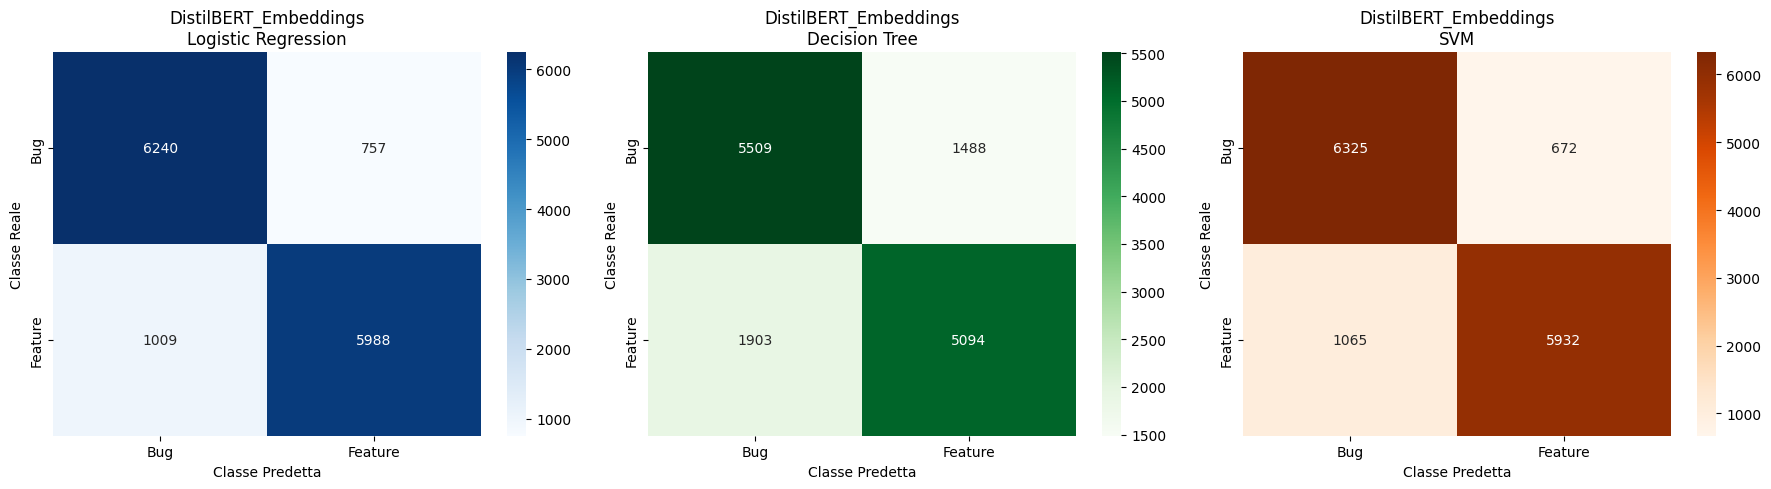

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Definiamo i nomi in base al mapping alfabetico (0: Bug, 1: Feature)
class_labels = ['Bug', 'Feature'] 

models_keys = ["logistic_regression", "decision_tree", "svm"]
titles = ["Logistic Regression", "Decision Tree", "SVM"]
cmaps = ["Blues", "Greens", "Oranges"]

for i, model_key in enumerate(models_keys):
    cm = final_results[exp_name][model_key]["confusion_matrix"]
    
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmaps[i], ax=axes[i],
                xticklabels=class_labels, yticklabels=class_labels)
    axes[i].set_title(f'{exp_name}\n{titles[i]}')
    axes[i].set_ylabel('Classe Reale')
    axes[i].set_xlabel('Classe Predetta')

plt.tight_layout()
plt.show()